In [1]:
# Imort libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read Data
df = pd.read_csv(
    r'C:\Users\Admin\Desktop\BIA Capstone Project\data\valid_purchases.csv'
    )

In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(392692, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 24.0+ MB


In [7]:
# Create a revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [8]:
# Create a month column
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   Revenue      392692 non-null  float64       
 9   Month        392692 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int64(2), object(3), period[M](1)
memory usage: 30.0+ MB


In [10]:
df['Revenue'].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [11]:
df['Revenue'].nlargest(10)

392226    168469.60
36521      77183.60
153588     38970.00
116868      8142.75
246041      7144.72
32199       6539.40
108204      6539.40
304623      4992.00
32197       4921.50
108200      4632.00
Name: Revenue, dtype: float64

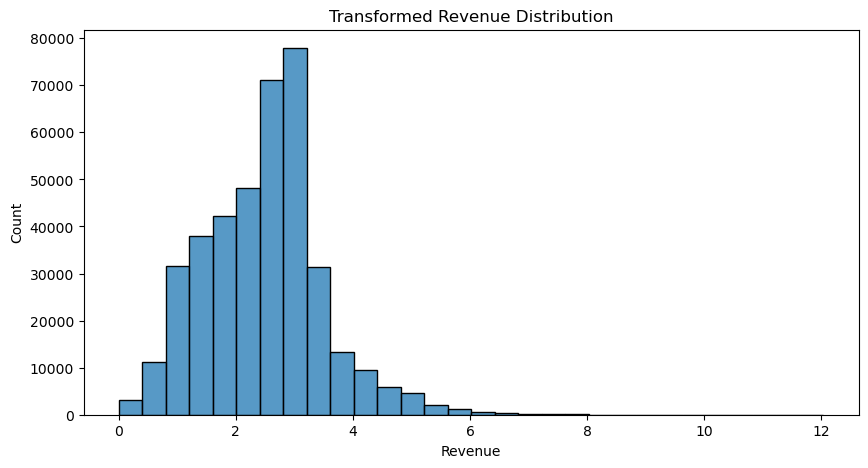

np.float64(448.5217789067741)

In [12]:
# Univariate Analysis Revenue Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df['Revenue']),
    bins=30
)

plt.title('Transformed Revenue Distribution')
plt.xlabel('Revenue')

plt.show()
df['Revenue'].skew()

OBSERVATION :-
Revenue distribution is highly right-skewed. Most transactions generates low revenue, while small number of transactions contribute exceptionally hgih revenue.
Identifying and retaining high revenue customers should be key business objective.

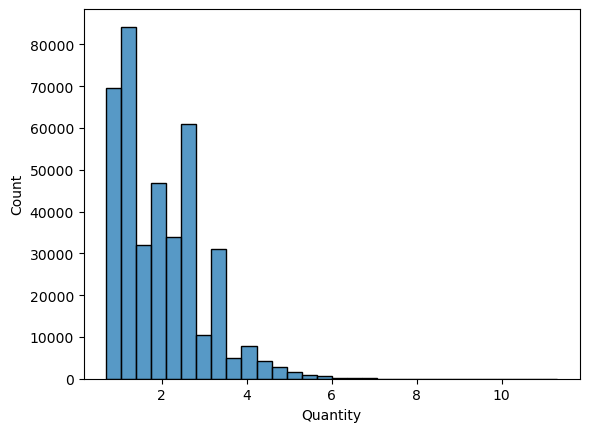

In [13]:
# Univariate Analysis for Quantity Distribution

sns.histplot(np.log1p(df['Quantity']), bins=30)
plt.show()

OBSERVATION :- As the number of quantity is less price is high. That means for less than 3 quantity people are paying high amount and for more than 3 quantites people are paying less which means most frequently people are buying for low price and bulk in quantity. 

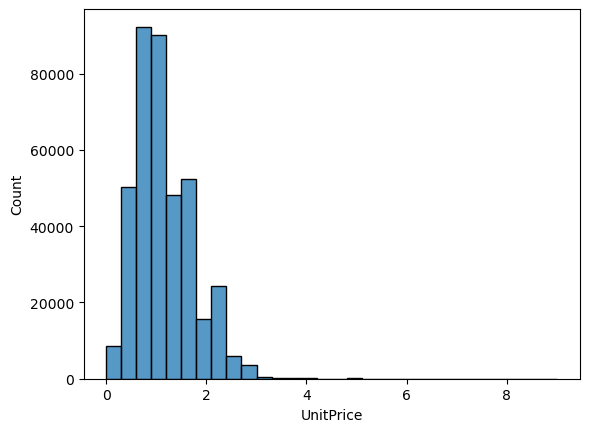

In [14]:
# Univariate Analysis for per/Unit Price Distribution
sns.histplot(np.log1p(df['UnitPrice']), bins=30)
plt.show()

Based on Univariate Analysis I got to know that data is highly right skewed. Most frequently customers are buying low price products but as all customers are not same so there are few luxury customers who bought high pricing products due to which data is right-skewed.

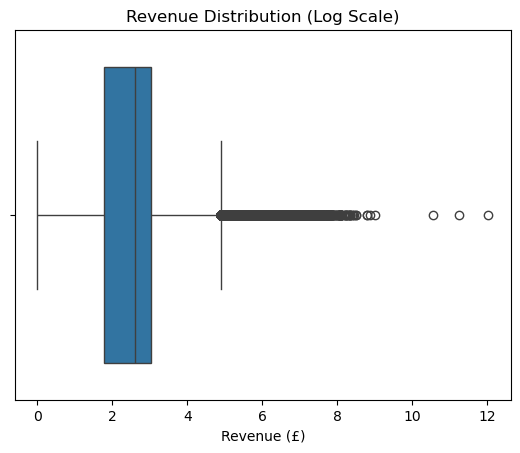

In [15]:
sns.boxplot(x=np.log1p(df['Revenue']))
plt.title('Revenue Distribution (Log Scale)')
plt.xlabel('Revenue (£)')
plt.show()

BIVARIATE ANALYSIS

In [16]:
# TOP 10 Customers by Revenue
country_revenue = (
    df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
)
country_revenue = country_revenue/1_000_000
country_revenue

Country
United Kingdom    7.285025
Netherlands       0.285446
EIRE              0.265262
Germany           0.228678
France            0.208934
Australia         0.138454
Spain             0.061559
Switzerland       0.056444
Belgium           0.041196
Sweden            0.038368
Name: Revenue, dtype: float64

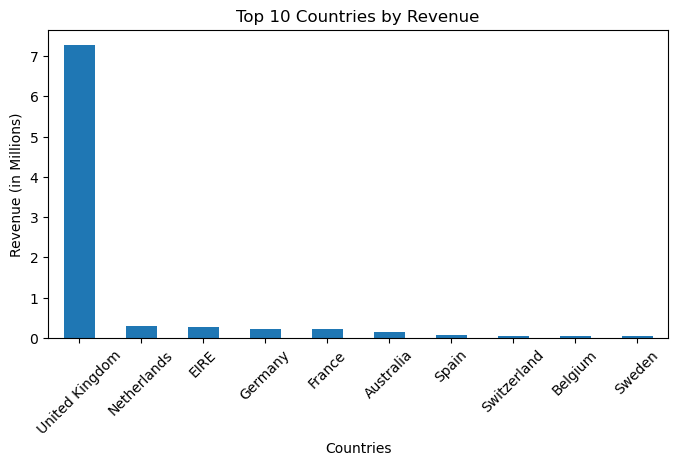

'UK contributes 81.97% of total revenue.'

In [17]:
plt.figure(figsize=(8,4))

country_revenue.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Countries')
plt.ylabel('Revenue (in Millions)')

plt.xticks(rotation=45)

plt.show()

uk_rev = df[df['Country'] == 'United Kingdom']['Revenue'].sum()
total_rev = df['Revenue'].sum()
uk_per = (uk_rev/total_rev) * 100
f'UK contributes {uk_per:.2f}% of total revenue.'

Observation :- This graph shows top 10 countries by revenue.
United Kingdom generates highest revenue.

In [18]:
# Top 10 Customers who generates high revenue
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

These are the top 10 customers who generate high revenue.

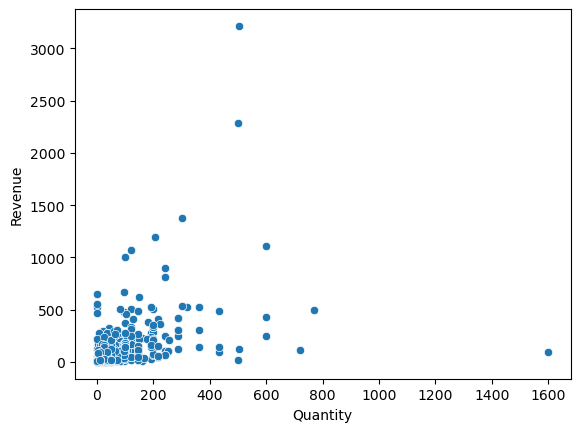

In [19]:
# Scatter plot showing random 10000 values pick from the data
sns.scatterplot(
    x='Quantity',
    y='Revenue',
    data=df.sample(10000)
)
plt.show()

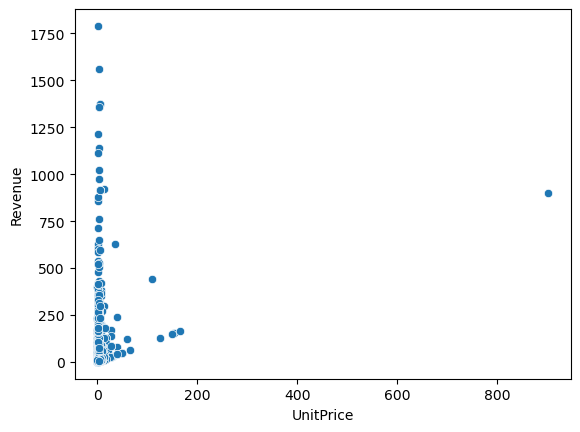

In [20]:
# Unit price vs Revenue
sns.scatterplot(
    x='UnitPrice',
    y='Revenue',
    data=df.sample(10000)
)
plt.show()

This shows most of the customers for per unit/price is higher which means for people are paying higher amount for low quantities.

In [21]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [22]:
# Monthly Revenue in millions
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue = monthly_revenue/1_000_000
monthly_revenue

Month
2010-12    0.570423
2011-01    0.568101
2011-02    0.446085
2011-03    0.594082
2011-04    0.468374
2011-05    0.677355
2011-06    0.660046
2011-07    0.598963
2011-08    0.644051
2011-09    0.950690
2011-10    1.035642
2011-11    1.156206
2011-12    0.517190
Freq: M, Name: Revenue, dtype: float64

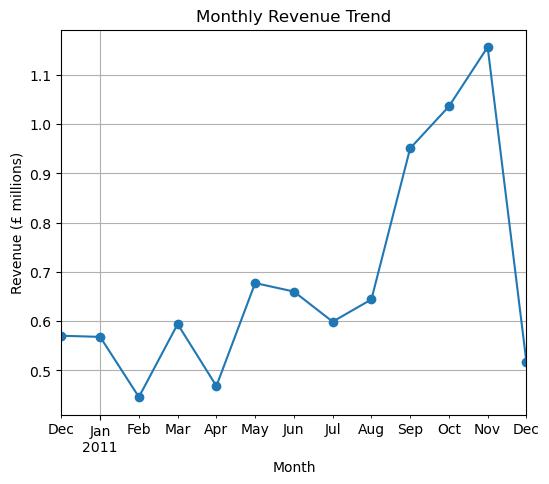

In [23]:
# Plot monthly revenue by millions
monthly_revenue.plot(
    kind='line',
    figsize=(6,5),
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£ millions)')
plt.grid(True)

plt.show()

OBSERVATION: This shows monthly revenue is higher during Sep, Oct & Nov as usually this are the most festive seasons and as it goes to December revenue drops.

In [24]:
df.to_csv('EDA.csv', index=False)

Revenue is highly right-skewed.
UK contributes X% of total revenue.
A small number of customers generate a large share of revenue.
Monthly revenue peaks during certain months.
High-value transactions exist, indicating potential VIP customers.